In [5]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pyproj
import folium

In [6]:
#datos de ingreso
dia_ivd = '20260401'
dia_fvd = '20260422'

In [7]:
# Ruta de la carpeta que contiene los archivos de desglosados zonal
ruta_carpeta = 'Z:/01 base_datos/41 Informe Diario CCZ/FMS 2025/SMART OPERATOR/mensajes ul-SC smart operator/mensajes SC-ul dia vencido/Consolidado'

# Fechas de inicio y fin para el filtro
fecha_inicio = f'{dia_ivd}'
fecha_fin = f'{dia_fvd}'

# Lista para almacenar los DataFrames
dataframes = []

# Recorrer todos los archivos en la carpeta
for nombre_archivo in os.listdir(ruta_carpeta):

    if nombre_archivo.endswith('_CONSOLIDADO_ULSC.csv'):

        # Extraer la fecha del nombre del archivo (YYYYMMDD)
        fecha_archivo = nombre_archivo[:8]

        # Verificar si la fecha está dentro del rango deseado
        if fecha_inicio <= fecha_archivo <= fecha_fin:

            ruta_archivo = os.path.join(ruta_carpeta, nombre_archivo)

            # Leer el archivo
            df = pd.read_csv(ruta_archivo, encoding='latin')

            # Eliminar filas completamente vacías
            df = df.dropna(how='all')

            # Crear la columna Fecha a partir del nombre del archivo
            df['Fecha'] = pd.to_datetime(fecha_archivo, format='%Y%m%d')

            # Agregar a la lista
            dataframes.append(df)

# Verificar si se encontraron DataFrames
if dataframes:
    # Consolidar todos los DataFrames en uno solo
    mensajes = pd.concat(dataframes, ignore_index=True)
else:
    print("No se encontraron archivos para consolidar.")

# Verificar resultado
mensajes.head()

,Tiempo,Destino,LÃ­nea,Tipo de evento,VehÃ­culo,Tabla,Servicio,Conductor,Estado,Mensajes,Usuario,Fecha
0,01-04-2026 19:38:26,VehÃ­culo,10504.0,SC >>UL,20635.0,5.0,CO11B0006,401491.0,Conductor confirmado,Buenas noches realizar pantalla a coordinadora...,DGUZMAN_104,2026-04-01
1,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,3,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01
2,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,2,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01
3,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,1,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01
4,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,5,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01


In [10]:
palabras = [
    'RUTERO',
    'RUTEROS',
    'ADELANTO',
    'ADELANTOS',
    'PARE',
    'ELECTRONICO',
    'ELECTRONICOS',
    'ELECTRÓNICO',
    'ELECTRÓNICOS',
    'EVITAR',
    'MANTENER',
    'CEROS',
    'RUTA',
    'LOGICA',
    'SEGUIMIENTO',
    'RETORNO',
    'EXCESIVOS',
    'REVISAR',
    'TRANSMILENIO',
    'SENTIDO',
    'RUTA',
    'VELOCIDAD',
    'INTERVALO',
    'FRECUENCIA',
    'CONVOY',
    'REGULAR'
]

In [11]:
import numpy as np

# Convertir a texto
mensajes['Mensajes'] = (
    mensajes['Mensajes']
    .astype(str)
    .str.upper()
)

# Crear patrón
patron = '|'.join(palabras)

# Crear bandera
mensajes['Mensaje_operacional'] = np.where(
    mensajes['Mensajes'].str.contains(
        patron,
        regex=True,
        na=False
    ),
    1,
    0
)

mensajes.head()

,Tiempo,Destino,LÃ­nea,Tipo de evento,VehÃ­culo,Tabla,Servicio,Conductor,Estado,Mensajes,Usuario,Fecha,Mensaje_operativo,Mensaje_operacional
0,01-04-2026 19:38:26,VehÃ­culo,10504.0,SC >>UL,20635.0,5.0,CO11B0006,401491.0,Conductor confirmado,BUENAS NOCHES REALIZAR PANTALLA A COORDINADORA...,DGUZMAN_104,2026-04-01,0,0
1,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,3,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NAN,NaN,2026-04-01,0,0
2,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,2,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NAN,NaN,2026-04-01,0,0
3,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,1,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NAN,NaN,2026-04-01,0,0
4,"01-04-2026 18:26:49,LÃ­nea,10504,SC >>UL,,5,,,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NAN,NaN,2026-04-01,0,0


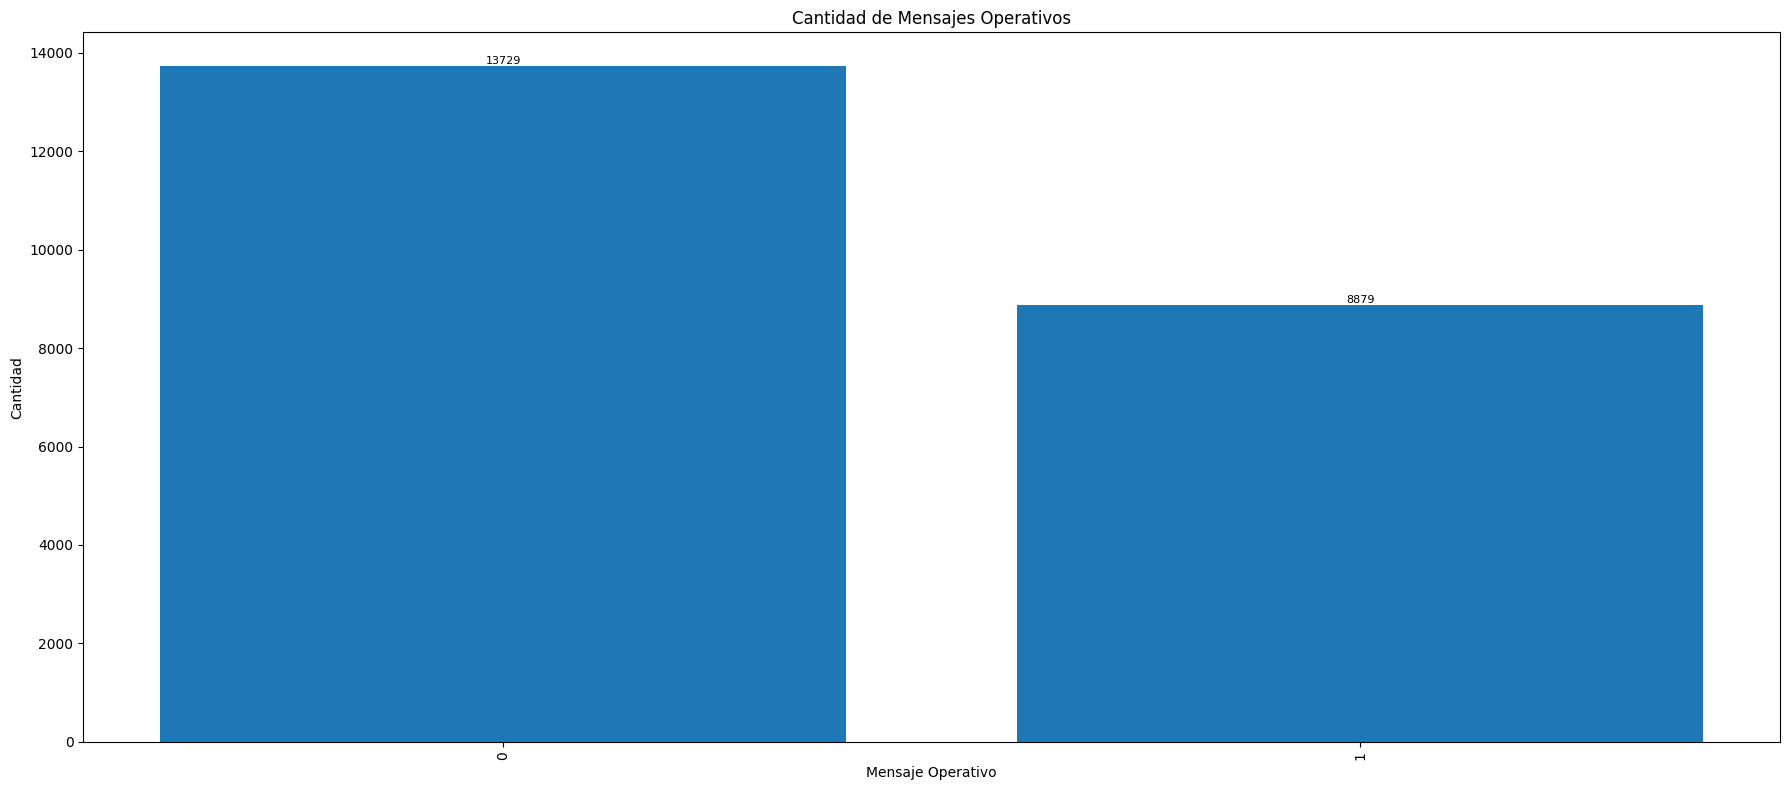

In [12]:
import matplotlib.pyplot as plt

# Filtrar solo donde exista mensaje operativo
temp = mensajes[
    mensajes['Mensaje_operacional'] == 1
].copy()

# Contar por mensaje
grafica = (
    temp['Mensaje_operativo']
    .astype(str)
    .str.upper()
    .str.strip()
    .value_counts()
    .reset_index()
)

# Renombrar columnas
grafica.columns = [
    'Mensaje_operativo',
    'Cantidad'
]

# Ordenar
grafica = grafica.sort_values(
    'Cantidad',
    ascending=False
)

# Crear gráfica
plt.figure(figsize=(18,8))

bars = plt.bar(
    grafica['Mensaje_operativo'],
    grafica['Cantidad']
)

# Etiquetas
for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        int(altura),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title(
    'Cantidad de Mensajes Operativos'
)

plt.xlabel('Mensaje Operativo')
plt.ylabel('Cantidad')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

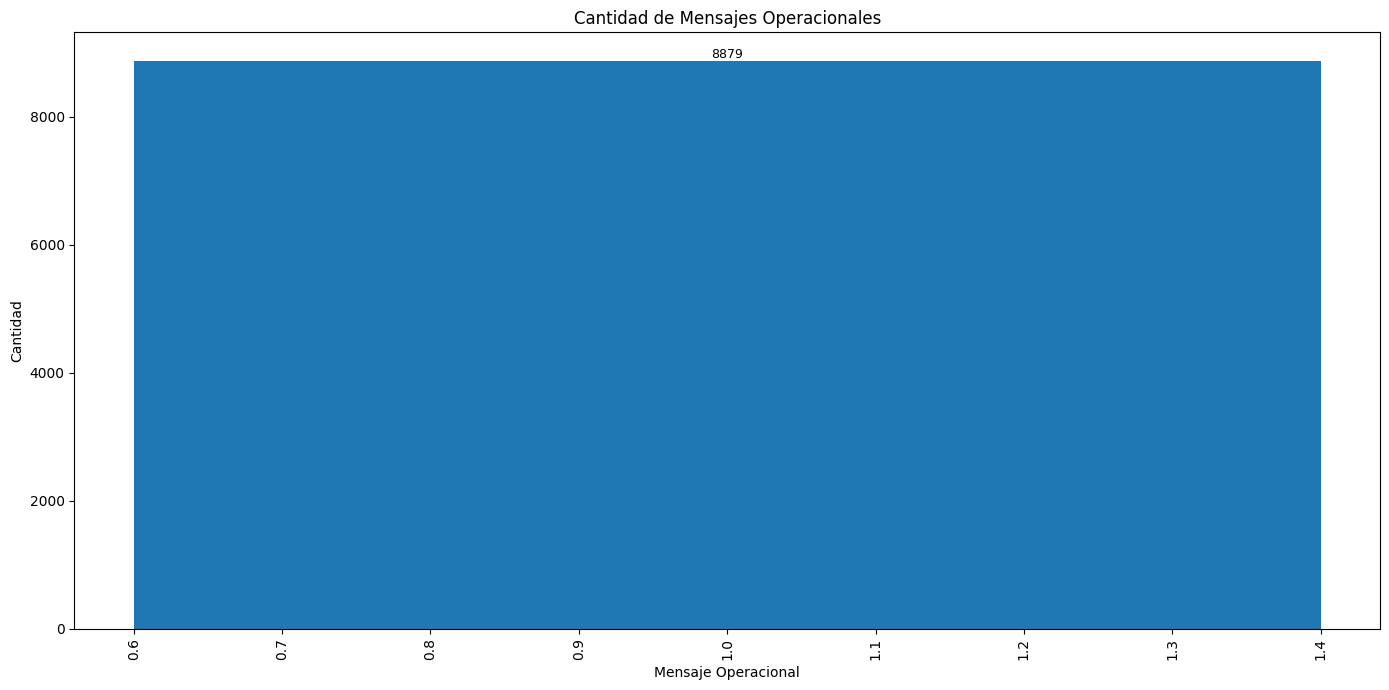

In [13]:
import matplotlib.pyplot as plt

# Filtrar solo registros donde exista mensaje operativo
temp = mensajes[
    mensajes['Mensaje_operativo'] == 1
].copy()

# Agrupar por mensaje operacional
grafica = (
    temp.groupby('Mensaje_operacional')
    .size()
    .reset_index(name='Cantidad')
)

# Ordenar de mayor a menor
grafica = grafica.sort_values(
    'Cantidad',
    ascending=False
)

# Crear gráfica
plt.figure(figsize=(14,7))

bars = plt.bar(
    grafica['Mensaje_operacional'],
    grafica['Cantidad']
)

# Etiquetas de datos
for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        int(altura),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Títulos
plt.title(
    'Cantidad de Mensajes Operacionales'
)

plt.xlabel('Mensaje Operacional')
plt.ylabel('Cantidad')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

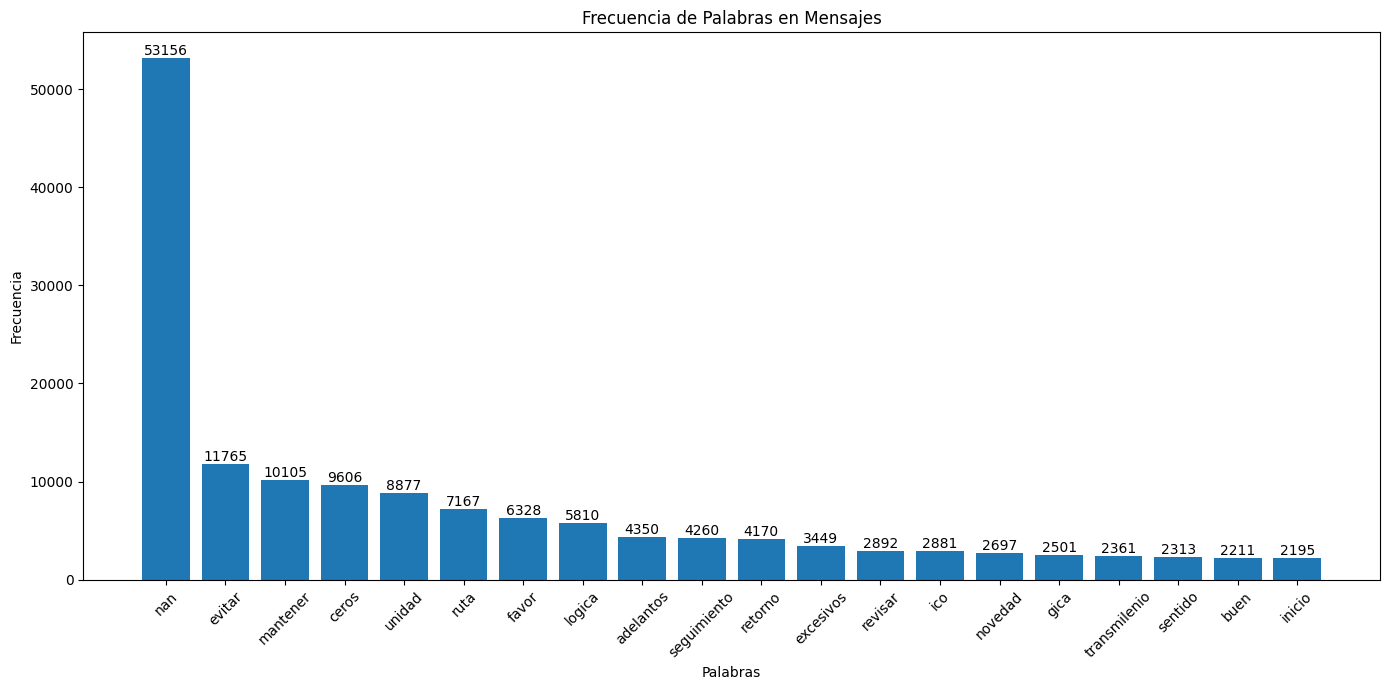

,Palabra,Frecuencia
6,nan,53156
185,evitar,11765
184,mantener,10105
11,ceros,9606
45,unidad,8877
50,ruta,7167
9,favor,6328
56,logica,5810
48,adelantos,4350
155,seguimiento,4260


In [14]:
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt

# Unir todos los mensajes
texto = ' '.join(
    mensajes['Mensajes']
    .fillna('')
    .astype(str)
    .str.lower()
)

# Limpiar texto
texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)

# Separar palabras
palabras = texto.split()

# Palabras a excluir
stopwords = [
    'de', 'la', 'el', 'y', 'en', 'a', 'que',
    'los', 'las', 'por', 'del', 'para',
    'con', 'se', 'un', 'una', 'al',
    'su', 'lo', 'es'
]

# Filtrar palabras
palabras = [
    p for p in palabras
    if p not in stopwords and len(p) > 2
]

# Contar frecuencia
frecuencia = Counter(palabras)

# DataFrame
freq_df = pd.DataFrame(
    frecuencia.items(),
    columns=['Palabra', 'Frecuencia']
)

# Top palabras
freq_df = freq_df.sort_values(
    'Frecuencia',
    ascending=False
).head(20)

# Gráfica
plt.figure(figsize=(14,7))

bars = plt.bar(
    freq_df['Palabra'],
    freq_df['Frecuencia']
)

# Etiquetas
for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

plt.title('Frecuencia de Palabras en Mensajes')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

freq_df.head(20)

In [8]:
mensajes.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/mensajes.csv', index=False)